In [ ]:
# =========================================
# 🚀 Setup for Google Colab
# =========================================

# Install SpectroChemPy with CP (TensorLy)
!pip install -q "spectrochempy@ git+https://github.com/spectrochempy/spectrochempy.git@master" >& install.log

# Clone the repo
!git clone https://github.com/atravert/jihane-octeo.git

# Move into repo
%cd jihane-octeo

print("✅ Setup complete")

In [2]:
import spectrochempy as scp

A = scp.read(r"data\silice_octeo_2_torr_eau\sample")  

NDDataset: [float64] a.u. (shape: (y:499, x:5549))

<Axes: xlabel='wavenumbers $\\mathrm{/\\ \\mathrm{cm}^{-1}}$', ylabel='absorbance $\\mathrm{/\\ \\mathrm{a.u.}}$'>

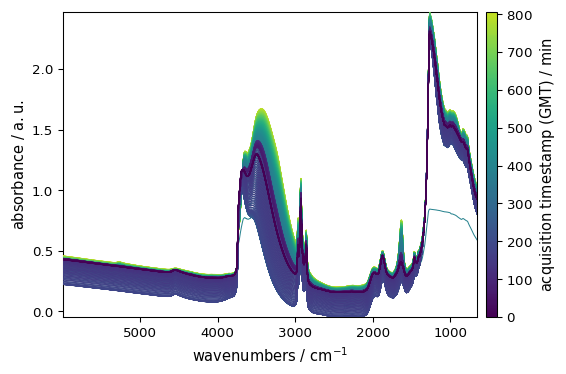

In [8]:
A.y = A.y - A.y[0]
A.y.ito('min')
A.plot(colorbar=True) 


# Analyse de la zone $\nu$(CH)

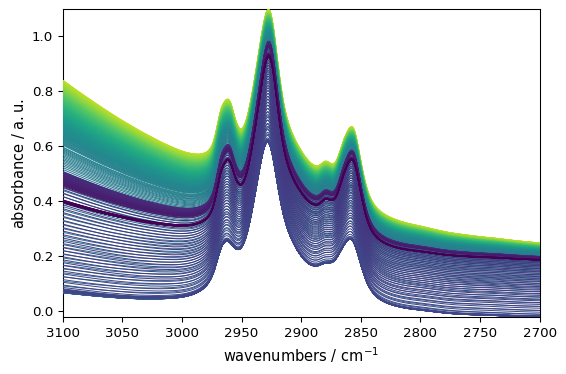

In [74]:
B = A[:,2700.:3100.]
_ = B.plot()

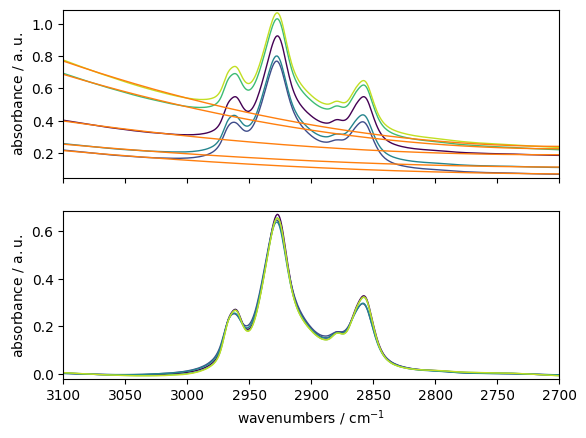

In [75]:

bl = scp.Baseline()
bl.ranges = [3100.,3050.], [2750., 2700.]
bl.order = 2

bl.fit(B[::100])
_ = bl.plot()


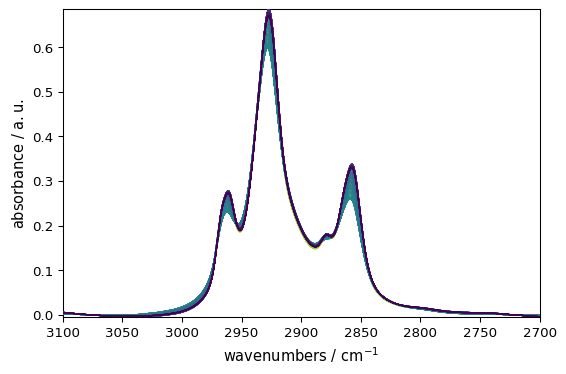

In [76]:
bl.fit(B[:362.])
_ = bl.corrected.plot()


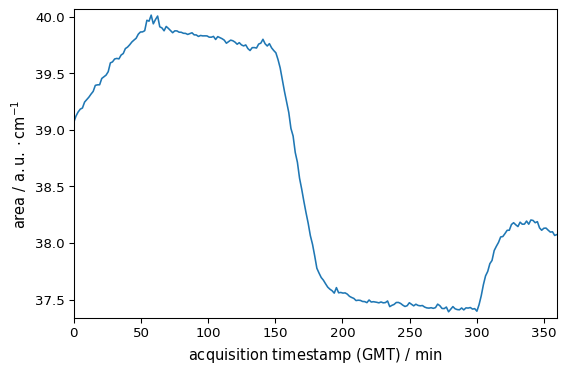

In [77]:
areas = scp.trapezoid(bl.corrected)
_ = areas[:360.].plot()

## observations:
- 0-60 mins légère augementation d'intensité pendant la 1ere heure (sous vide secondaire)
- 60 - 120 mins: stabilisation et très légère diminution sous 2 torrs H2O
- 120-180 mins: diminution d'intensité (chaffage 25-188°C saous 2 torrs d'eau)
- diminution moindre lors du pallier à 188°C
- reprise lors de la descente en température.

# Analyse de la zone $\nu+\delta$(HOH)

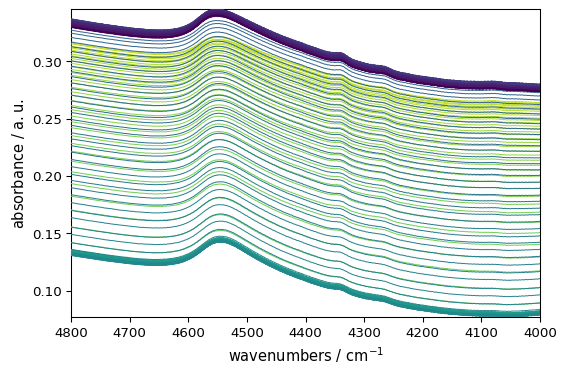

In [83]:
C = A[:360.,4800.:4000.]
_ = C.plot()

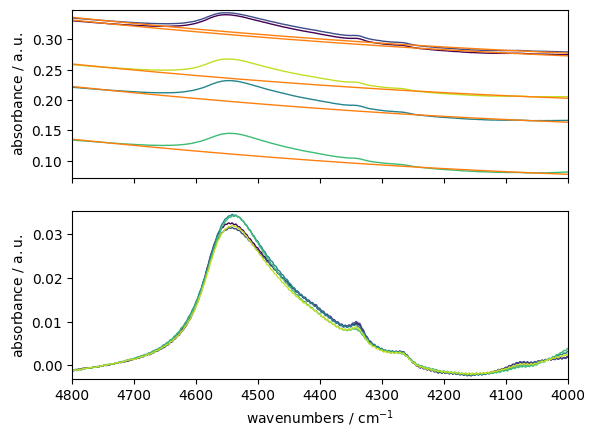

In [84]:

bl = scp.Baseline()
bl.ranges = [4800.,4700.], [4300., 4000.]
bl.order = 2

bl.fit(C[::50])
_ = bl.plot()


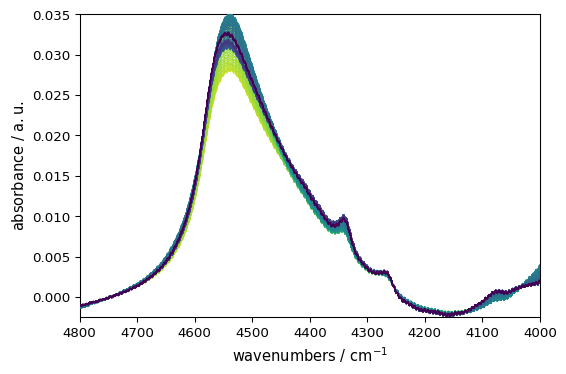

In [85]:
bl.fit(C)
_ = bl.corrected.plot()

<Axes: xlabel='acquisition timestamp (GMT) $\\mathrm{/\\ \\mathrm{min}}$', ylabel='area $\\mathrm{/\\ \\mathrm{a.u.} \\cdot \\mathrm{cm}^{-1}}$'>

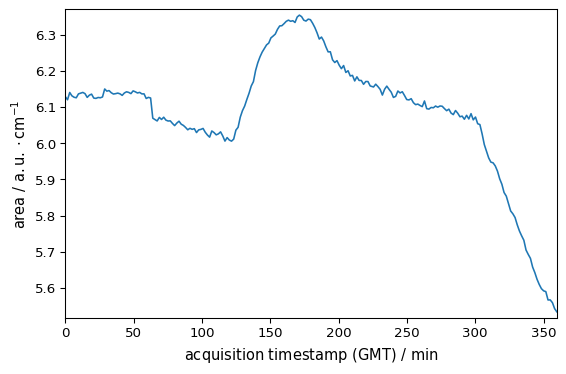

In [86]:
areas = scp.trapezoid(bl.corrected[:,4800.:4200.])
areas.plot()

<Axes: xlabel='wavenumbers $\\mathrm{/\\ \\mathrm{cm}^{-1}}$', ylabel='absorbance $\\mathrm{/\\ \\mathrm{a.u.}}$'>

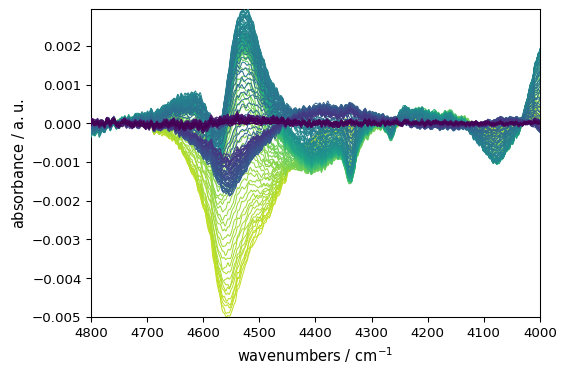

In [87]:
nudelta_diff = bl.corrected - bl.corrected[0]
nudelta_diff.plot()

## observations:
- 0-60 mins stable pendant la 1ere heure (sous vide secondaire)
- 60 - 120 mins:  diminution sous 2 torrs H2O
- 120-180 mins: augmentation d'intensité (chaffage 25-188°C sous 2 torrs d'eau)
- diminutioncontinue lors du pallier à 188°C
- diminution plus forte lors de la descente en température.

# Analyse de la zone H2O a 5200 cm-1

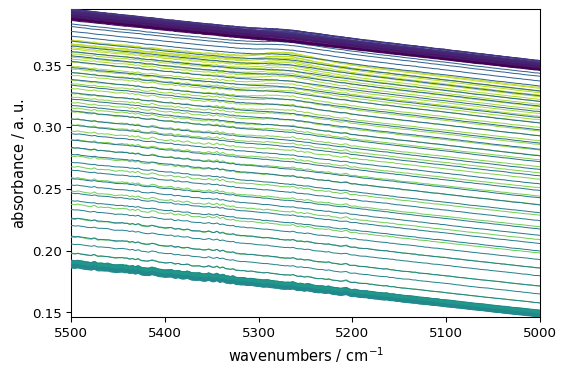

In [88]:
D = A[:360.,5500.:5000.]
_ = D.plot()

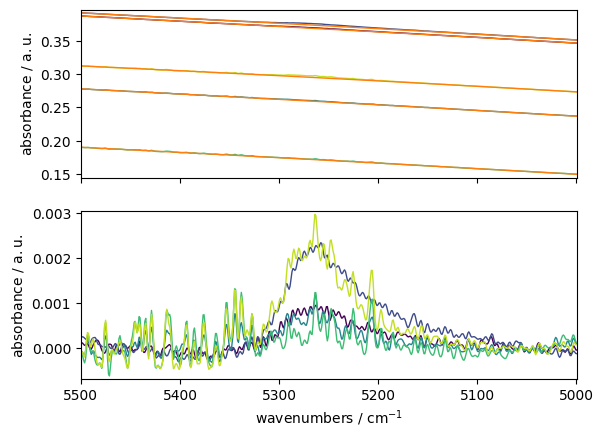

In [91]:

bl = scp.Baseline()
bl.ranges = [5500.,5400.], [5100., 5000.]
bl.order = 2

bl.fit(D[::50])
_ = bl.plot()

<Axes: xlabel='wavenumbers $\\mathrm{/\\ \\mathrm{cm}^{-1}}$', ylabel='absorbance $\\mathrm{/\\ \\mathrm{a.u.}}$'>

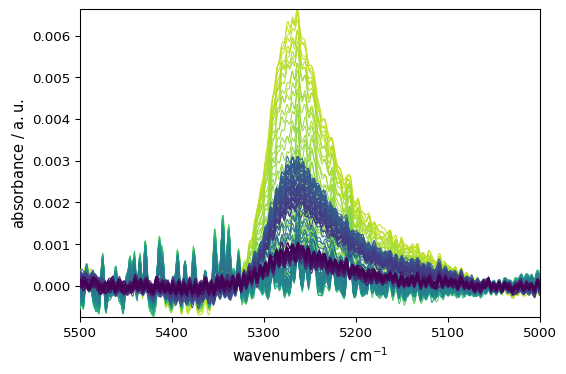

In [ ]:
bl.fit(D)
_ = bl.corrected.plot()

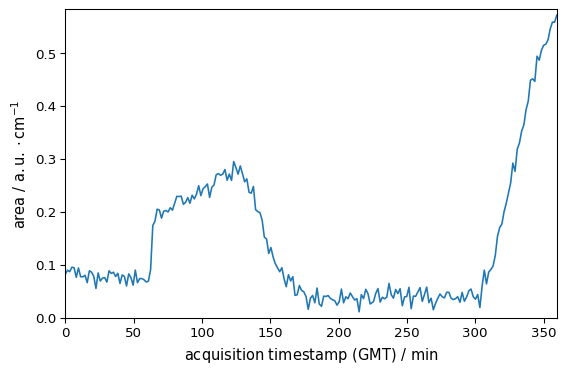

In [94]:
areas = scp.trapezoid(bl.corrected)
_ = areas.plot()

## observations:
- 0-60 mins stable pendant la 1ere heure (sous vide secondaire)
- 60 - 120 mins:  augmentation sous 2 torrs H2O
- 120-180 mins: diminution d'intensité (chauffage 25-188°C sous 2 torrs d'eau)
- stable lors du pallier à 188°C
- réaugmentation forte lors de la descente en température ==> réadosrption imortante d'eau.